In [4]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import math
import copy

import matplotlib.pyplot as plt
from data_loader import *
from utils import *
from VAE import *
from VAE_joint import *
from combined_data_loader import *
from Optimization_multi_node import *
from Optimization_single_node import *
import pickle

In [5]:
data=pd.read_csv('load_data_city_4_2.csv')

In [6]:
class Args:
    def __init__(self):
        # ----- problem / optnet -----
        self.T = 24
        self.base_mva = 100.0
        self.capacity_scale = 4.5
        self.ramp_rate = 0.5
        self.voll = 200.0
        self.vosp = 50.0
        self.M_beta = 1e4
        self.pwl_segments = 10

        # IMPORTANT: add these to match gurobi
        self.reserve_up_ratio = 0.05
        self.reserve_dn_ratio = 0.02
        self.rt_up_ratio = 3.0
        self.rt_dn_ratio = 0.5

        self.N_scen = 20       # <== OptNet真正求解的场景池 (即 K)
        self.S_full = 100       # VAE 现场吐出的大量候选场景数 (S 池)
        self.K_rand = 0       # K里面有多少条纯随机保留(防过拟合)
        self.tau_gumbel = 1.0     # Gumbel Softmax 温度
        self.eps_uniform = 0.1 # 防震荡平滑参数
        self.lambda_div = 1e5   # [新增] 避免多头选到同一个场景的相互排斥惩罚力度

        # ----- 分段训练控制参数 -----
        self.device = "cuda"
       #self.batch_size = 32   # (注意: 原来你的叫 dfl_batch_size, 统一改成 batch_size 给 DataLoader 读)
        self.train_batch_size = 8
        self.test_batch_size = 8
        self.solver = "ECOS"
        
        self.filter_epochs = 5 # Stage 2 (训Filter) 轮数
        self.filter_lr = 1e-3   # Stage 2 学习率
        self.dfl_epochs = 1     # Stage 3 (联合微调) 轮数 (端到端微调极耗时，一般1-3轮即收敛)
        self.dfl_lr = 1e-6      # Stage 3 学习率 (必须极小，防崩坏)
        
args = Args()

In [7]:
set_seed(42)
data_path = "load_data_city_4_2.csv"
target_nodes = [f"4-2-{i}" for i in range(11)]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eps_search=pd.read_csv('../Result/eps_search.csv')
eps=int(eps_search[eps_search['model']=='vae_m']['eps'])
data=pd.read_csv(data_path)
data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
data_2022 = data[data["DATETIME"].dt.year == 2022].copy()
Lmin, Lmax = system_hourly_load_minmax(data_2022, datetime_col="DATETIME",node_cols=target_nodes)
Lmax_total=Lmax.sum(0)# (24,)
Lmin_total=Lmin.sum(0) # (24,)
args.eps_value=eps

In [8]:
import pickle
with open('../Result/VAE/models_m.pkl', 'rb') as f:
    models_m = pickle.load(f)
with open('../Result/VAE/handlers_m.pkl', 'rb') as f:
    handlers_m = pickle.load(f)
with open('../Result/VAE/pack_data_m.pkl', 'rb') as f:
    pack_data_m = pickle.load(f)

with open('../Result/VAE/window_pack_m_vae_test.pkl', 'rb') as f:
    window_pack_m_vae_val = pickle.load(f)
with open('../Result/VAE/window_pack_s_vae_train.pkl', 'rb') as f:
    window_pack_s_vae_train = pickle.load(f)
with open('../Result/VAE/window_pack_m_vae_val.pkl', 'rb') as f:
    window_pack_m_vae_val = pickle.load(f)

In [16]:
import copy
import time
import os
import psutil
import torch
from tqdm import tqdm

def DFL_train(
    dfl,
    train_dataset,
    args,
    z_temp=1.0,
    problem_mode="saa",
    train_mode="dfl",
    filter_kwargs=None,
    lambda_div=1e5,
    max_batches=None,
    profile_time=False,
    warmup_batches=0,
    return_timing=False,
):
    """
    记录：
      - forward / backward / batch total 时间
      - CPU memory (RSS)
      - GPU memory (allocated / peak)
    """
    dfl.train()
    device = next(dfl.parameters()).device
    process = psutil.Process(os.getpid())

    def sync_if_needed():
        if profile_time and device.type == "cuda":
            torch.cuda.synchronize()

    def mean_or_none(xs):
        return None if len(xs) == 0 else float(sum(xs) / len(xs))

    def get_cpu_mem_mb():
        return process.memory_info().rss / (1024 ** 2)

    def get_gpu_mem_mb():
        if device.type == "cuda":
            return torch.cuda.memory_allocated(device) / (1024 ** 2)
        return 0.0

    def get_gpu_peak_mem_mb():
        if device.type == "cuda":
            return torch.cuda.max_memory_allocated(device) / (1024 ** 2)
        return 0.0

    train_bs = int(
        getattr(
            args,
            "train_batch_size",
            getattr(args, "dfl_batch_size", getattr(args, "batch_size", 8))
        )
    )

    eval_mode = str(getattr(args, "eval_mode", "soft")).lower()
    avoid_rand_duplicate = bool(getattr(args, "avoid_rand_duplicate", False))
    if getattr(dfl, "scenario_filter", None) is not None:
        if hasattr(dfl.scenario_filter, "eval_mode"):
            dfl.scenario_filter.eval_mode = eval_mode
        if hasattr(dfl.scenario_filter, "avoid_rand_duplicate"):
            dfl.scenario_filter.avoid_rand_duplicate = avoid_rand_duplicate

    if filter_kwargs is None:
        filter_kwargs = {
            "tau_gumbel": float(getattr(args, "tau_mix", 1.0)),
            "eps_uniform": float(getattr(args, "eps_uniform", 0.1)),
        }

    div_type = str(getattr(args, "div_type", "inner")).lower()
    div_eps = float(getattr(args, "div_eps", 1e-8))

    if train_mode == "filter_only" and getattr(dfl, "scenario_filter", None) is not None:
        for p in dfl.parameters():
            p.requires_grad = False
        for p in dfl.scenario_filter.parameters():
            p.requires_grad = True

        optim_params_filter = [p for p in dfl.scenario_filter.parameters() if p.requires_grad]
        optim_params_predictor = []

        optim = torch.optim.Adam(
            optim_params_filter,
            lr=float(getattr(args, "lr", getattr(args, "filter_lr", 1e-3))),
        )
    else:
        for p in dfl.parameters():
            p.requires_grad = True

        if getattr(dfl, "scenario_filter", None) is not None:
            optim_params_filter = [p for p in dfl.scenario_filter.parameters() if p.requires_grad]
        else:
            optim_params_filter = []

        optim_params_predictor = [p for p in dfl.predictor.parameters() if p.requires_grad]

        optim = torch.optim.Adam(
            [
                {"params": optim_params_filter, "lr": float(getattr(args, "filter_lr", 1e-3))},
                {"params": optim_params_predictor, "lr": float(getattr(args, "dfl_lr", 1e-5))},
            ],
        )

    loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=train_bs,
        shuffle=True,
    )
    epochs = int(getattr(args, "epochs", 1))
    train_losses = []

    timing_info = {
        "profile_time": bool(profile_time),
        "warmup_batches": int(warmup_batches),
        "max_batches": None if max_batches is None else int(max_batches),
        "effective_batches_per_epoch": len(loader),
        "device": str(device),
        "train_mode": str(train_mode),
        "problem_mode": str(problem_mode),
        "div_type": str(div_type),
        "train_batch_size": int(train_bs),

        "num_ran_batches": 0,
        "num_profiled_batches": 0,

        # time
        "batch_times_sec": [],
        "forward_times_sec": [],
        "backward_times_sec": [],

        # cpu memory
        "cpu_mem_mb_before_forward": [],
        "cpu_mem_mb_after_forward": [],
        "cpu_mem_mb_after_backward": [],

        # gpu memory
        "gpu_mem_mb_before_forward": [],
        "gpu_mem_mb_after_forward": [],
        "gpu_mem_mb_after_backward": [],
        "gpu_peak_mem_mb": [],

        # averages
        "avg_batch_time_sec": None,
        "avg_forward_time_sec": None,
        "avg_backward_time_sec": None,

        "avg_cpu_mem_mb_before_forward": None,
        "avg_cpu_mem_mb_after_forward": None,
        "avg_cpu_mem_mb_after_backward": None,

        "avg_gpu_mem_mb_before_forward": None,
        "avg_gpu_mem_mb_after_forward": None,
        "avg_gpu_mem_mb_after_backward": None,
        "avg_gpu_peak_mem_mb": None,

        "estimated_epoch_time_sec": None,
    }

    for ep in tqdm(range(epochs), desc=f"Train ({train_mode})", leave=True):
        pbar = tqdm(loader, desc=f"Ep {ep+1}/{epochs}", leave=False)
        epoch_task_loss, epoch_div_loss, samples_cnt = 0.0, 0.0, 0

        for batch_idx, (X_all, y_true) in enumerate(pbar):
            if max_batches is not None and batch_idx >= max_batches:
                break

            sync_if_needed()
            t_batch_0 = time.time()

            X_all = X_all.to(device).float()
            y_true = y_true.to(device).float()

            optim.zero_grad(set_to_none=True)

            kwargs = dict(
                solver=getattr(args, "solver", None),
                return_aux=False,
                return_filter_aux=True,
                predictor_n_samples=int(getattr(args, "S_full", getattr(args, "N_scen", 50))),
                predictor_kwargs={
                    "z_temp": z_temp,
                    "cpu_offload": False,
                },
                filter_kwargs=filter_kwargs,
            )

            if str(problem_mode).lower() == "dro":
                dtype = getattr(dfl, "optnet_dtype", torch.float64)
                kwargs.update(
                    hourly_load_min_sys=torch.as_tensor(args.Lmin, device=device, dtype=dtype),
                    hourly_load_max_sys=torch.as_tensor(args.Lmax, device=device, dtype=dtype),
                    eps=torch.as_tensor(args.eps_value, device=device, dtype=dtype),
                )

            # -------------------------
            # memory before forward
            # -------------------------
            sync_if_needed()
            if device.type == "cuda":
                torch.cuda.reset_peak_memory_stats(device)

            cpu_before_fwd = get_cpu_mem_mb()
            gpu_before_fwd = get_gpu_mem_mb()

            # -------------------------
            # forward
            # -------------------------
            sync_if_needed()
            t0 = time.time()
            out = dfl(X_all, y_true, **kwargs)
            sync_if_needed()
            t1 = time.time()
            forward_time = t1 - t0

            cpu_after_fwd = get_cpu_mem_mb()
            gpu_after_fwd = get_gpu_mem_mb()

            if isinstance(out, (tuple, list)):
                loss_vec = out[0]
                aux_filter = out[-1]
            else:
                loss_vec = out
                aux_filter = None

            task_loss_val = loss_vec.mean()

            div_loss_val = torch.tensor(0.0, device=device)
            if aux_filter is not None and ("p" in aux_filter) and (lambda_div > 0):
                p = aux_filter["p"].clamp_min(div_eps)
                p = p / p.sum(dim=-1, keepdim=True).clamp_min(div_eps)

                B_curr, K_curr, _ = p.shape

                if div_type == "inner":
                    if K_curr > 1:
                        inner_product = torch.bmm(p, p.transpose(1, 2))
                        eye = torch.eye(K_curr, device=device, dtype=torch.bool).unsqueeze(0).expand(B_curr, -1, -1)
                        off_diag = inner_product[~eye]
                        div_loss_val = (off_diag ** 2).mean()

                elif div_type == "kl":
                    if K_curr > 1:
                        p_i = p.unsqueeze(2)
                        p_j = p.unsqueeze(1)
                        kl_ij = (p_i * (p_i.log() - p_j.log())).sum(dim=-1)
                        kl_ji = (p_j * (p_j.log() - p_i.log())).sum(dim=-1)
                        skl = 0.5 * (kl_ij + kl_ji)
                        eye = torch.eye(K_curr, device=device, dtype=torch.bool).unsqueeze(0).expand(B_curr, -1, -1)
                        div_loss_val = -skl[~eye].mean()

                elif div_type == "entropy":
                    H = -(p * p.log()).sum(dim=-1).mean()
                    div_loss_val = -H

                else:
                    raise ValueError(f"Unknown div_type={div_type}, choose from inner|kl|entropy")

            loss = task_loss_val + lambda_div * div_loss_val

            # -------------------------
            # backward
            # -------------------------
            sync_if_needed()
            t0 = time.time()
            loss.backward()
            sync_if_needed()
            t1 = time.time()
            backward_time = t1 - t0

            cpu_after_bwd = get_cpu_mem_mb()
            gpu_after_bwd = get_gpu_mem_mb()
            gpu_peak = get_gpu_peak_mem_mb()

            if len(optim_params_filter) > 0:
                torch.nn.utils.clip_grad_norm_(optim_params_filter, 1.0)
            if len(optim_params_predictor) > 0:
                torch.nn.utils.clip_grad_norm_(optim_params_predictor, 1.0)

            optim.step()

            sync_if_needed()
            t_batch_1 = time.time()
            batch_time = t_batch_1 - t_batch_0

            timing_info["num_ran_batches"] += 1

            if profile_time and batch_idx >= warmup_batches:
                timing_info["batch_times_sec"].append(batch_time)
                timing_info["forward_times_sec"].append(forward_time)
                timing_info["backward_times_sec"].append(backward_time)

                timing_info["cpu_mem_mb_before_forward"].append(cpu_before_fwd)
                timing_info["cpu_mem_mb_after_forward"].append(cpu_after_fwd)
                timing_info["cpu_mem_mb_after_backward"].append(cpu_after_bwd)

                timing_info["gpu_mem_mb_before_forward"].append(gpu_before_fwd)
                timing_info["gpu_mem_mb_after_forward"].append(gpu_after_fwd)
                timing_info["gpu_mem_mb_after_backward"].append(gpu_after_bwd)
                timing_info["gpu_peak_mem_mb"].append(gpu_peak)

            B_size = X_all.shape[0]
            epoch_task_loss += float(task_loss_val.detach().cpu()) * B_size
            epoch_div_loss += float(div_loss_val.detach().cpu()) * B_size
            samples_cnt += B_size

            postfix = {
                "Task": float(task_loss_val.detach().cpu()),
                "Div": float(div_loss_val.detach().cpu()),
                "Type": div_type,
                "BS": train_bs,
            }
            if profile_time and len(timing_info["batch_times_sec"]) > 0:
                postfix["t_fwd"] = mean_or_none(timing_info["forward_times_sec"])
                postfix["t_bwd"] = mean_or_none(timing_info["backward_times_sec"])
                postfix["cpu_mb"] = mean_or_none(timing_info["cpu_mem_mb_after_backward"])

            pbar.set_postfix(postfix)

        train_losses.append({
            "task": epoch_task_loss / max(samples_cnt, 1),
            "div": epoch_div_loss / max(samples_cnt, 1),
            "div_type": div_type,
            "train_batch_size": train_bs,
        })

    timing_info["num_profiled_batches"] = len(timing_info["batch_times_sec"])

    timing_info["avg_batch_time_sec"] = mean_or_none(timing_info["batch_times_sec"])
    timing_info["avg_forward_time_sec"] = mean_or_none(timing_info["forward_times_sec"])
    timing_info["avg_backward_time_sec"] = mean_or_none(timing_info["backward_times_sec"])

    timing_info["avg_cpu_mem_mb_before_forward"] = mean_or_none(timing_info["cpu_mem_mb_before_forward"])
    timing_info["avg_cpu_mem_mb_after_forward"] = mean_or_none(timing_info["cpu_mem_mb_after_forward"])
    timing_info["avg_cpu_mem_mb_after_backward"] = mean_or_none(timing_info["cpu_mem_mb_after_backward"])

    timing_info["avg_gpu_mem_mb_before_forward"] = mean_or_none(timing_info["gpu_mem_mb_before_forward"])
    timing_info["avg_gpu_mem_mb_after_forward"] = mean_or_none(timing_info["gpu_mem_mb_after_forward"])
    timing_info["avg_gpu_mem_mb_after_backward"] = mean_or_none(timing_info["gpu_mem_mb_after_backward"])
    timing_info["avg_gpu_peak_mem_mb"] = mean_or_none(timing_info["gpu_peak_mem_mb"])

    if timing_info["avg_batch_time_sec"] is not None:
        timing_info["estimated_epoch_time_sec"] = timing_info["avg_batch_time_sec"] * len(loader)

    if return_timing:
        return dfl, train_losses, timing_info
    return dfl, train_losses

def benchmark_dfl_runtime_nscen(
    args,
    optimization_mode,
    problem_mode,
    data_path,
    target_nodes,
    pack_data_m,
    models_m,
    device,
    nscen_list=(20, 50, 100, 150),
    max_batches=4,
    warmup_batches=1,
    train_mode="dfl",
    use_random_selector=True,
    seed=0,
    save_csv_path=None,
):
    def is_so(x):
        return str(x).lower() in {"so", "saa"}

    def is_multi(x):
        return str(x).lower() in {"multi", "multinode"}

    multi = is_multi(optimization_mode)

    if multi:
        SO_Manager = IEEE14_Reserve_SO_Manager_MultiNode
        DRO_Manager = IEEE14_Reserve_DRO_Manager_MultiNode

        SAA_DA_OptNet = MultiNode_Reserve_SAA_DA_OptNet
        DRO_DA_OptNet = MultiNode_Reserve_DRO_DA_OptNet
        RT_OptNet = MultiNode_Reserve_RT_OptNet

        DFL_SO_Class = DFL_model_vae_MultiNode
        DFL_DRO_Class = DFL_model_vae_DRO_MultiNode
    else:
        SO_Manager = IEEE14_Reserve_SO_Manager_SingleNode
        DRO_Manager = IEEE14_Reserve_DRO_Manager_SingleNode

        SAA_DA_OptNet = SingleNode_Reserve_SAA_DA_OptNet
        DRO_DA_OptNet = SingleNode_Reserve_DRO_DA_OptNet
        RT_OptNet = SingleNode_Reserve_RT_OptNet

        DFL_SO_Class = DFL_model_vae_SingleNode
        DFL_DRO_Class = DFL_model_vae_DRO_SingleNode

    set_seed(seed)
    train_data = Dataset_load_multi_node_vae(
        data_path=data_path,
        node_cols=target_nodes,
        flag="train",
        train_length=8760,
        val_ratio=0.2,
        seed=42,
        scale=True,
    )

    best_z = pack_data_m["_JOINT_"]["best_z_temp"]

    def build_predictor(joint_model, dataset):
        return Joint_vae_predictor(
            joint_model=copy.deepcopy(joint_model),
            dataset=dataset,
        ).to(device)

    results = []

    for nscen in nscen_list:
        print("\n" + "=" * 100)
        print(f"[Benchmark] N_scen = {nscen}")
        print("=" * 100)

        set_seed(seed)
        args_local = copy.deepcopy(args)
        args_local.N_scen = int(nscen)
        args_local.epochs = 1

        K = int(getattr(args_local, "N_scen", 50))
        K_rand = int(getattr(args_local, "K_rand", 0))

        def make_filter():
            return ScenarioFilter(
                args=args_local,
                prob_type="multi" if multi else "single",
                T=24,
                N_nodes=11,
                K=K,
                K_rand=K_rand,
                hidden=128,
            ).to(device)

        if is_so(problem_mode):
            mgr_local = SO_Manager(args_local)
            optnet_DA = SAA_DA_OptNet(mgr=mgr_local, N_scen=args_local.N_scen, T=24).to(device)
            DFLClass = DFL_SO_Class
            mode_str = "SO"
        else:
            mgr_local = DRO_Manager(args_local)
            optnet_DA = DRO_DA_OptNet(mgr=mgr_local, N_scen=args_local.N_scen, T=24).to(device)
            DFLClass = DFL_DRO_Class
            mode_str = "DRO"

        optnet_RT = RT_OptNet(mgr=mgr_local, T=24).to(device)

        predictor = build_predictor(models_m, train_data)
        filter_module = make_filter()

        dfl = DFLClass(
            mgr=mgr_local,
            optnet_DA=optnet_DA,
            optnet_RT=optnet_RT,
            predictor=predictor,
            scenario_filter=filter_module,
            n_scen=args_local.N_scen,
            solver="ECOS",
        ).to(device)

        if train_mode == "dfl":
            for p in dfl.predictor.parameters():
                p.requires_grad_(True)

            if use_random_selector:
                dfl.scenario_filter = RandomScenarioSelector(n_scen=int(args_local.N_scen)).to(device)

            lambda_div_used = float(getattr(args_local, "lambda_div", 1e5))
        else:
            lambda_div_used = float(getattr(args_local, "lambda_div", 1e5))

        try:
            t0 = time.time()
            dfl, train_logs, timing_info = DFL_train(
                dfl=dfl,
                train_dataset=train_data,
                args=args_local,
                z_temp=best_z,
                problem_mode=problem_mode,
                train_mode=train_mode,
                lambda_div=lambda_div_used,
                max_batches=max_batches,
                profile_time=True,
                warmup_batches=warmup_batches,
                return_timing=True,
            )
            wall_clock_sec = time.time() - t0

            row = {
                "status": "ok",
                "optimization_mode": "multi" if multi else "single",
                "problem_mode": mode_str,
                "N_scen": int(args_local.N_scen),
                "S_full": int(getattr(args_local, "S_full", -1)),
                "train_batch_size": int(getattr(args_local, "train_batch_size", getattr(args_local, "batch_size", 8))),
                "avg_batch_time_sec": timing_info["avg_batch_time_sec"],
                "avg_forward_time_sec": timing_info["avg_forward_time_sec"],
                "avg_backward_time_sec": timing_info["avg_backward_time_sec"],
                "avg_cpu_mem_mb_before_forward": timing_info["avg_cpu_mem_mb_before_forward"],
                "avg_cpu_mem_mb_after_forward": timing_info["avg_cpu_mem_mb_after_forward"],
                "avg_cpu_mem_mb_after_backward": timing_info["avg_cpu_mem_mb_after_backward"],
                "avg_gpu_mem_mb_before_forward": timing_info["avg_gpu_mem_mb_before_forward"],
                "avg_gpu_mem_mb_after_forward": timing_info["avg_gpu_mem_mb_after_forward"],
                "avg_gpu_mem_mb_after_backward": timing_info["avg_gpu_mem_mb_after_backward"],
                "avg_gpu_peak_mem_mb": timing_info["avg_gpu_peak_mem_mb"],
                "estimated_epoch_time_sec": timing_info["estimated_epoch_time_sec"],
                "wall_clock_sec": wall_clock_sec,
            }

        except Exception as e:
            row = {
                "status": "failed",
                "optimization_mode": "multi" if multi else "single",
                "problem_mode": mode_str,
                "N_scen": int(args_local.N_scen),
                "S_full": int(getattr(args_local, "S_full", -1)),
                "train_batch_size": int(getattr(args_local, "train_batch_size", getattr(args_local, "batch_size", 8))),
                "error": str(e),
            }

        results.append(row)
        print(row)

    try:
        import pandas as pd
        df = pd.DataFrame(results)
        if save_csv_path is not None:
            df.to_csv(save_csv_path, index=False)
            print(f"[Saved CSV] {save_csv_path}")
        return results, df
    except Exception:
        return results, None

In [19]:
# =========================================================
# benchmark config
# =========================================================
optimization_mode = "multi"
problem_mode = "so"
forecasting_mode = "joint"

# 构建 manager，主要为了拿拓扑或者映射
if optimization_mode == "multi":
    mgr = IEEE14_Reserve_SO_Manager_MultiNode(args)
else:
    mgr = IEEE14_Reserve_SO_Manager_SingleNode(args)

# 写入 DRO 边界（即使现在是 SO，也保留兼容）
if optimization_mode == "multi":
    args.Lmin = mgr.map_11load_to_14bus(Lmin)
    args.Lmax = mgr.map_11load_to_14bus(Lmax)
else:
    args.Lmin = Lmin_total
    args.Lmax = Lmax_total

# =========================================================
# 基本超参
# =========================================================
args.run_stage2 = True
args.run_stage3 = False

args.eval_mode = "discrete"
args.dfl_epochs = 1
args.dfl_lr = 1e-6
args.filter_lr = 1e-3
args.N_scen = 20          # benchmark 时会被覆盖
args.K_rand = 10
args.filter_epochs = 1
args.clip_predictor = 1.0
args.S_full = 200

args.lambda_div = 1e5
args.lambda_div_stage3 = 1e5

args.epochs = 1
args.div_type = "kl"

# =========================================================
# 强烈建议：benchmark 时把 batch size 调小
# 尤其是要测 backward / cvxpylayer 时
# =========================================================
args.train_batch_size = 1
args.test_batch_size = 1

# 如果你后面测到 150/200 仍然炸，可以进一步尝试：
# args.S_full = 100

# =========================================================
# Stage A 风格 benchmark：train_mode='dfl'
# =========================================================
results_stageA, df_stageA = benchmark_dfl_runtime_nscen(
    args=args,
    optimization_mode=optimization_mode,
    problem_mode=problem_mode,
    data_path=data_path,
    target_nodes=target_nodes,
    pack_data_m=pack_data_m,
    models_m=models_m,
    device=device,
    nscen_list=(10, 20,30),
    max_batches=1,              # 建议只跑 3 个 batch
    warmup_batches=0,           # 第 1 个 batch 作为 warmup，不计入平均
    train_mode="dfl",           # Stage A
    use_random_selector=True,
    seed=0,
    save_csv_path="benchmark_stageA_runtime.csv",
)

print("\n===== Stage A benchmark results =====")
if df_stageA is not None:
    cols_to_show = [
        "status",
        "N_scen",
        "S_full",
        "train_batch_size",
        "avg_batch_time_sec",
        "avg_forward_time_sec",
        "avg_backward_time_sec",
        "avg_cpu_mem_mb_before_forward",
        "avg_cpu_mem_mb_after_forward",
        "avg_cpu_mem_mb_after_backward",
        "avg_gpu_mem_mb_before_forward",
        "avg_gpu_mem_mb_after_forward",
        "avg_gpu_mem_mb_after_backward",
        "avg_gpu_peak_mem_mb",
        "estimated_epoch_time_sec",
    ]

    cols_to_show = [c for c in cols_to_show if c in df_stageA.columns]
    print(df_stageA[cols_to_show])
else:
    for row in results_stageA:
        print(row)


[Benchmark] N_scen = 10


/home/zyz/.local/lib/python3.8/site-packages/torch/nn/init.py:412: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


K_rand 10
K_model 0
eps_uniform 0.1
tau_gumbel 1.0
eval_mode discrete
avoid_rand_duplicate False


Train (dfl):   0%|          | 0/1 [00:00<?, ?it/s]

Train (dfl): 100%|██████████| 1/1 [00:01<00:00,  1.12s/it]


{'status': 'ok', 'optimization_mode': 'multi', 'problem_mode': 'SO', 'N_scen': 10, 'S_full': 200, 'train_batch_size': 1, 'avg_batch_time_sec': 1.1160638332366943, 'avg_forward_time_sec': 0.12161445617675781, 'avg_backward_time_sec': 0.9904747009277344, 'avg_cpu_mem_mb_before_forward': 1754.08984375, 'avg_cpu_mem_mb_after_forward': 1754.08984375, 'avg_cpu_mem_mb_after_backward': 1754.05859375, 'avg_gpu_mem_mb_before_forward': 30.09912109375, 'avg_gpu_mem_mb_after_forward': 31.33935546875, 'avg_gpu_mem_mb_after_backward': 31.87548828125, 'avg_gpu_peak_mem_mb': 32.19482421875, 'estimated_epoch_time_sec': 325.89063930511475, 'wall_clock_sec': 1.1282391548156738}

[Benchmark] N_scen = 20
K_rand 10
K_model 10
eps_uniform 0.1
tau_gumbel 1.0
eval_mode discrete
avoid_rand_duplicate False


Train (dfl): 100%|██████████| 1/1 [00:03<00:00,  3.57s/it]
/home/zyz/miniconda3/envs/Meta_DFL/lib/python3.8/site-packages/cvxpy/reductions/solvers/solving_chain.py:246: UserWarning: Your problem has too many parameters for efficient DPP compilation. We suggest setting 'ignore_dpp = True'.
  warnings.warn(


{'status': 'ok', 'optimization_mode': 'multi', 'problem_mode': 'SO', 'N_scen': 20, 'S_full': 200, 'train_batch_size': 1, 'avg_batch_time_sec': 3.5626943111419678, 'avg_forward_time_sec': 0.2432539463043213, 'avg_backward_time_sec': 3.316124200820923, 'avg_cpu_mem_mb_before_forward': 1754.55859375, 'avg_cpu_mem_mb_after_forward': 1754.55859375, 'avg_cpu_mem_mb_after_backward': 1754.59765625, 'avg_gpu_mem_mb_before_forward': 30.1044921875, 'avg_gpu_mem_mb_after_forward': 31.3798828125, 'avg_gpu_mem_mb_after_backward': 31.91845703125, 'avg_gpu_peak_mem_mb': 32.6357421875, 'estimated_epoch_time_sec': 1040.3067388534546, 'wall_clock_sec': 3.576810598373413}

[Benchmark] N_scen = 30
K_rand 10
K_model 20
eps_uniform 0.1
tau_gumbel 1.0
eval_mode discrete
avoid_rand_duplicate False


Train (dfl): 100%|██████████| 1/1 [00:06<00:00,  6.55s/it]

{'status': 'ok', 'optimization_mode': 'multi', 'problem_mode': 'SO', 'N_scen': 30, 'S_full': 200, 'train_batch_size': 1, 'avg_batch_time_sec': 6.5397679805755615, 'avg_forward_time_sec': 0.3297874927520752, 'avg_backward_time_sec': 6.206754446029663, 'avg_cpu_mem_mb_before_forward': 1756.09765625, 'avg_cpu_mem_mb_after_forward': 1756.09765625, 'avg_cpu_mem_mb_after_backward': 1756.09765625, 'avg_gpu_mem_mb_before_forward': 30.109375, 'avg_gpu_mem_mb_after_forward': 31.419921875, 'avg_gpu_mem_mb_after_backward': 31.9658203125, 'avg_gpu_peak_mem_mb': 34.22119140625, 'estimated_epoch_time_sec': 1909.612250328064, 'wall_clock_sec': 6.552652359008789}
[Saved CSV] benchmark_stageA_runtime.csv

===== Stage A benchmark results =====
  status  N_scen  S_full  train_batch_size  avg_batch_time_sec  \
0     ok      10     200                 1            1.116064   
1     ok      20     200                 1            3.562694   
2     ok      30     200                 1            6.539768   



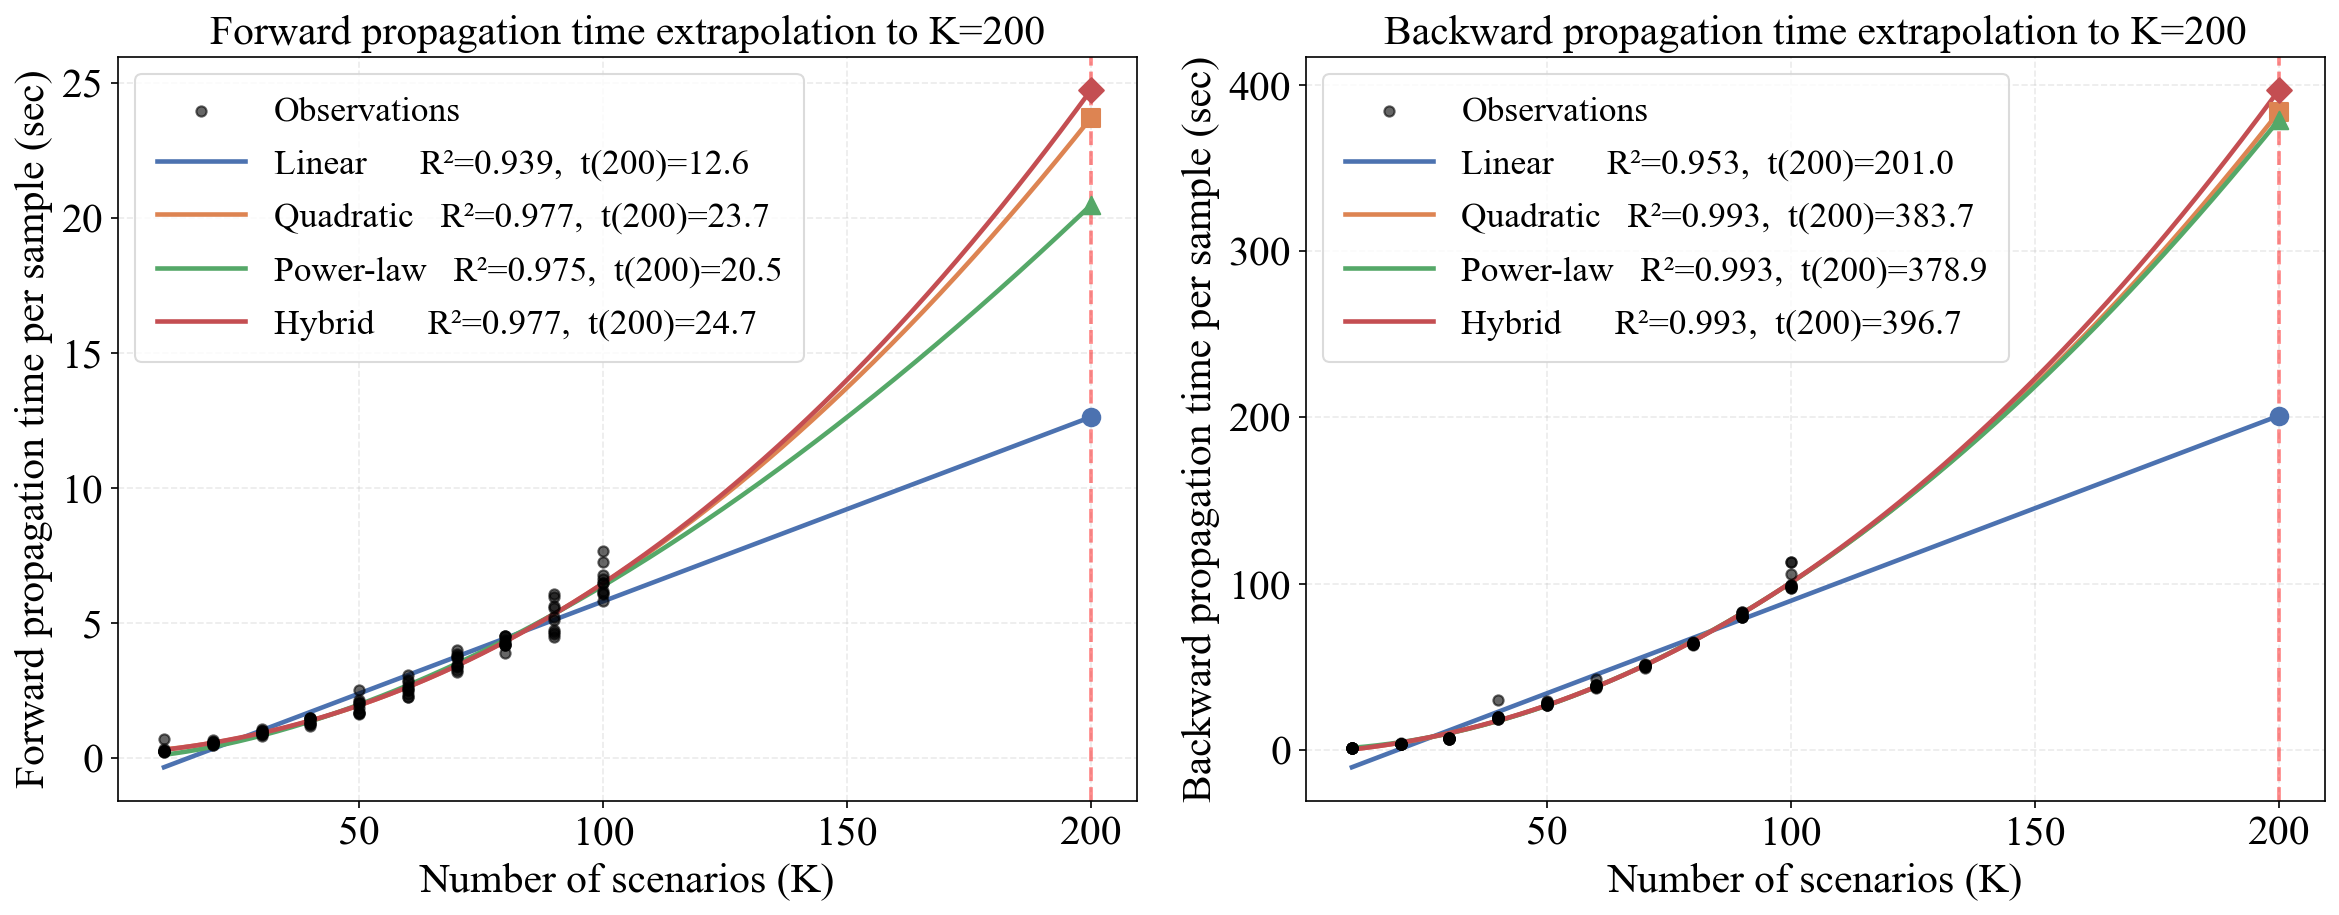

In [29]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib as mpl
from matplotlib import font_manager as fm

# =========================
# 0. 字体设置
# =========================
font_path = "../times.ttf"   # 或绝对路径
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()
mpl.rcParams["font.family"] = font_name

# =========================
# 1. 读取数据
# =========================
df = pd.read_csv("benchmark_stageA_runtime_memory_batch10.csv")

# =========================
# 2. 工具函数
# =========================
def parse_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return ast.literal_eval(x)

def linear_model(x, a, b):
    return a * x + b

def quad_model(x, a, b, c):
    return a * x**2 + b * x + c

def power_model(x, a, p):
    return a * x**p

def hybrid_model(x, a, p, b, c):
    return a * x**p + b * x + c

def r2_score_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

def expand_samples(df, n_col, time_col):
    x_all, y_all = [], []
    for _, row in df.iterrows():
        n = float(row[n_col])
        vals = parse_list(row[time_col])
        for v in vals:
            x_all.append(n)
            y_all.append(float(v))
    return np.array(x_all, dtype=float), np.array(y_all, dtype=float)

def fit_models(x_all, y_all):
    results = {}

    popt_lin, _ = curve_fit(linear_model, x_all, y_all)
    y_lin = linear_model(x_all, *popt_lin)
    results["Linear"] = {
        "params": popt_lin,
        "r2": r2_score_manual(y_all, y_lin),
        "func": linear_model,
        "color": "#4C72B0",
        "marker": "o"
    }

    popt_quad, _ = curve_fit(quad_model, x_all, y_all)
    y_quad = quad_model(x_all, *popt_quad)
    results["Quadratic"] = {
        "params": popt_quad,
        "r2": r2_score_manual(y_all, y_quad),
        "func": quad_model,
        "color": "#DD8452",
        "marker": "s"
    }

    popt_pow, _ = curve_fit(power_model, x_all, y_all, p0=[0.01, 1.5], maxfev=20000)
    y_pow = power_model(x_all, *popt_pow)
    results["Power-law"] = {
        "params": popt_pow,
        "r2": r2_score_manual(y_all, y_pow),
        "func": power_model,
        "color": "#55A868",
        "marker": "^"
    }

    popt_hyb, _ = curve_fit(hybrid_model, x_all, y_all, p0=[0.001, 1.5, 0.1, 0.0], maxfev=50000)
    y_hyb = hybrid_model(x_all, *popt_hyb)
    results["Hybrid"] = {
        "params": popt_hyb,
        "r2": r2_score_manual(y_all, y_hyb),
        "func": hybrid_model,
        "color": "#C44E52",
        "marker": "D"
    }

    return results

def plot_panel(ax, x_all, y_all, results, title, ylabel, N_pred=200):
    x_smooth = np.linspace(x_all.min(), N_pred, 500)

    # 原始散点
    ax.scatter(
        x_all, y_all,
        color="black", s=24, alpha=0.60,
        label="Observations", zorder=3
    )

    # 拟合曲线 + 合并结果到 legend
    for name in ["Linear", "Quadratic", "Power-law", "Hybrid"]:
        res = results[name]
        func = res["func"]
        p = res["params"]
        color = res["color"]
        marker = res["marker"]

        pred = func(N_pred, *p)
        label = f"{name:<10}  R²={res['r2']:.3f},  t(200)={pred:.1f}"

        ax.plot(
            x_smooth, func(x_smooth, *p),
            color=color, linewidth=2.2, label=label, zorder=2
        )

        ax.scatter(
            [N_pred], [pred],
            color=color, s=70, marker=marker, zorder=4
        )

    ax.axvline(N_pred, color="red", linestyle="--", alpha=0.45, linewidth=1.8)

    ax.set_title(title, fontsize=20)
    ax.set_xlabel("Number of scenarios (K)", fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)

    ax.grid(True, linestyle="--", alpha=0.25)
    ax.legend(
        loc="upper left",
        fontsize=17,
        frameon=True,
        facecolor="white",
        edgecolor="lightgray",
        handlelength=2.5,
        borderpad=0.6,
        labelspacing=0.6
    )

# =========================
# 3. 提取 forward / backward
# =========================
x_fwd, y_fwd = expand_samples(df, "N_scen", "forward_times_sec")
x_bwd, y_bwd = expand_samples(df, "N_scen", "backward_times_sec")

# =========================
# 4. 拟合
# =========================
results_fwd = fit_models(x_fwd, y_fwd)
results_bwd = fit_models(x_bwd, y_bwd)

# =========================
# 5. 全局绘图参数
# =========================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

# =========================
# 6. 画两个子图
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), dpi=150)

plot_panel(
    axes[0],
    x_fwd, y_fwd, results_fwd,
    title="Forward propagation time extrapolation to K=200",
    ylabel="Forward propagation time per sample (sec)",
    N_pred=200
)

plot_panel(
    axes[1],
    x_bwd, y_bwd, results_bwd,
    title="Backward propagation time extrapolation to K=200",
    ylabel="Backward propagation time per sample (sec)",
    N_pred=200
)

plt.tight_layout()
plt.savefig("../Figure/time_analysis.pdf", dpi=1000, bbox_inches="tight")
plt.show()